In [50]:
import sys
import os

# Add parent directory to path to import from app
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta, timezone
from app.repositories.price_data import fetch_bulk_price_data_for_tickers


In [51]:
tickers = ['SPY', 'QQQ', 'GLD', 'AAL', 'TSLA', 'NVDA', 'AMD', 'KR', 'BTC', 'ETH', 'IGSB', 'UTEN', 'COST', 'PLTR', 'GS', 'ADBE']

start = '2020-10-15'
end = '2025-10-15'

data = fetch_bulk_price_data_for_tickers(tickers, start, end, 'daily')

In [52]:
df = pd.DataFrame.from_dict(data)
print(df.tail(5))


              BTC   UTEN    AAL   IGSB    NVDA    TSLA     GLD    PLTR  \
date                                                                     
2025-10-08  54.65  44.17  11.80  52.91  189.10  438.65  372.25  183.55   
2025-10-09  53.59  44.13  11.61  52.88  192.53  435.56  365.47  185.48   
2025-10-10  51.61  44.47  11.52  52.93  183.14  413.27  369.24  175.41   
2025-10-13  51.32  44.47  11.74  53.01  188.31  435.89  378.09  177.19   
2025-10-14  49.90  44.59  12.19  53.04  180.02  429.21  381.09  179.74   

               SPY    ADBE      GS     KR     QQQ    COST     AMD  
date                                                               
2025-10-08  673.00  348.71  776.86  68.13  611.50  914.80  235.51  
2025-10-09  671.19  347.47  780.26  67.55  610.72  942.89  233.00  
2025-10-10  653.12  337.37  764.23  67.79  589.48  930.23  214.77  
2025-10-13  663.05  339.34  787.76  67.13  602.04  935.40  216.41  
2025-10-14  662.21  335.90  770.98  69.13  598.08  946.60  217.99  


In [53]:
data = pd.DataFrame(data['ADBE'])
data.rename(columns={'close':'price'}, inplace=True)
print(data.tail(5))
data.info()


             price
date              
2025-10-08  348.71
2025-10-09  347.47
2025-10-10  337.37
2025-10-13  339.34
2025-10-14  335.90
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2020-10-15 to 2025-10-14
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   1255 non-null   float64
dtypes: float64(1)
memory usage: 19.6 KB


In [54]:
data['SMA1'] = data['price'].rolling(window=55).mean()
data['SMA2'] = data['price'].rolling(window=365).mean()


data.tail(5)


,price,SMA1,SMA2
date,,,
2025-10-08,348.71,353.932182,447.309205
2025-10-09,347.47,353.478182,446.957068
2025-10-10,337.37,352.853091,446.572986
2025-10-13,339.34,352.282909,446.206603
2025-10-14,335.90,351.671091,445.859753


<Axes: xlabel='date'>

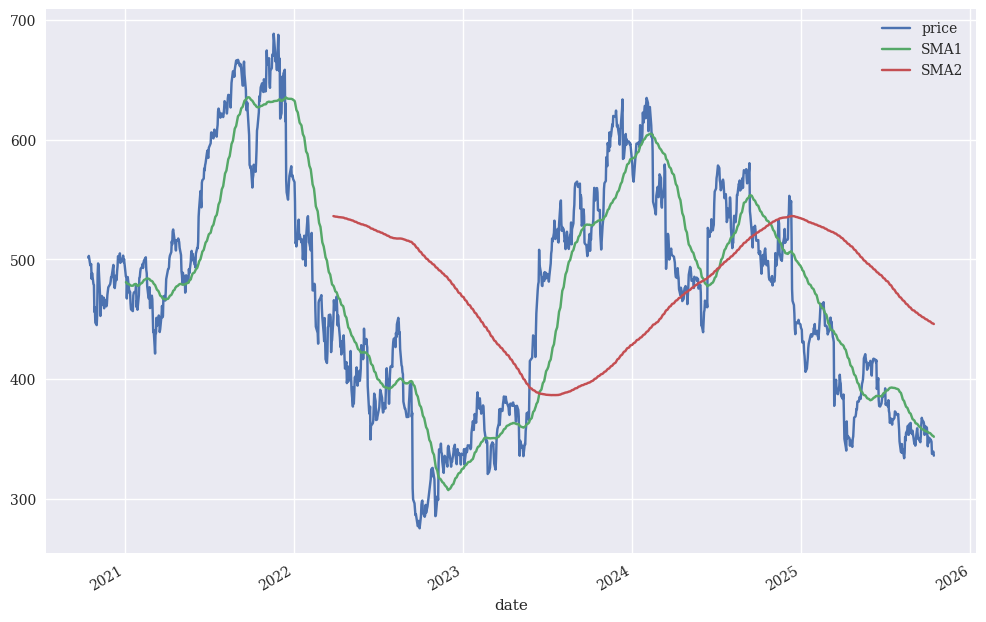

In [55]:
%matplotlib inline
from pylab import mpl, plt 

plt.style.use('seaborn-v0_8') 
mpl.rcParams['font.family'] = 'serif'
data.plot(figsize=(12, 8))


In [56]:
data['position'] = np.where(data['SMA1'] > data['SMA2'], 1, -1) #Generate trading signals
data.dropna(inplace=True)

In [57]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))
data['strategy'] = data['position'].shift(1) * data['returns']

In [58]:
data[['returns', 'strategy']].sum()
data[['returns', 'strategy']].sum().apply(np.exp)

returns     0.745484
strategy    0.827555
dtype: float64

<Axes: xlabel='date'>

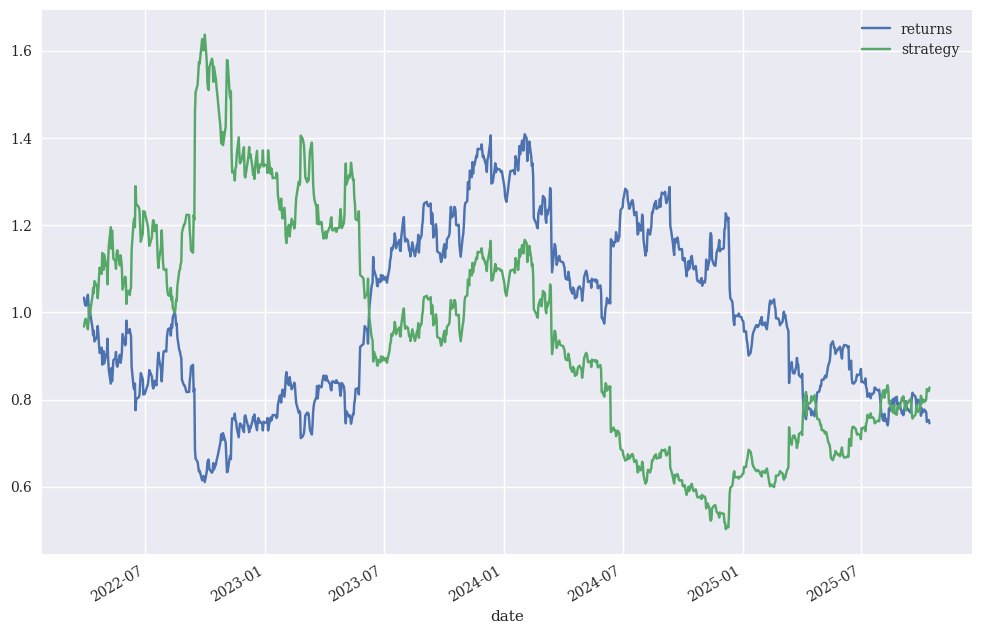

In [59]:
data[['returns', 'strategy']].cumsum().apply(np.exp).plot(figsize=(12, 8))

In [60]:
annualized_ret = np.exp(data[['returns', 'strategy']].mean()*365)-1
annualized_vol = (data[['returns', 'strategy']].apply(np.exp)-1).std()*365**0.5
print(annualized_ret)
print(annualized_vol)

returns    -0.113487
strategy   -0.074689
dtype: float64
returns     0.423788
strategy    0.431058
dtype: float64


<Axes: xlabel='date'>

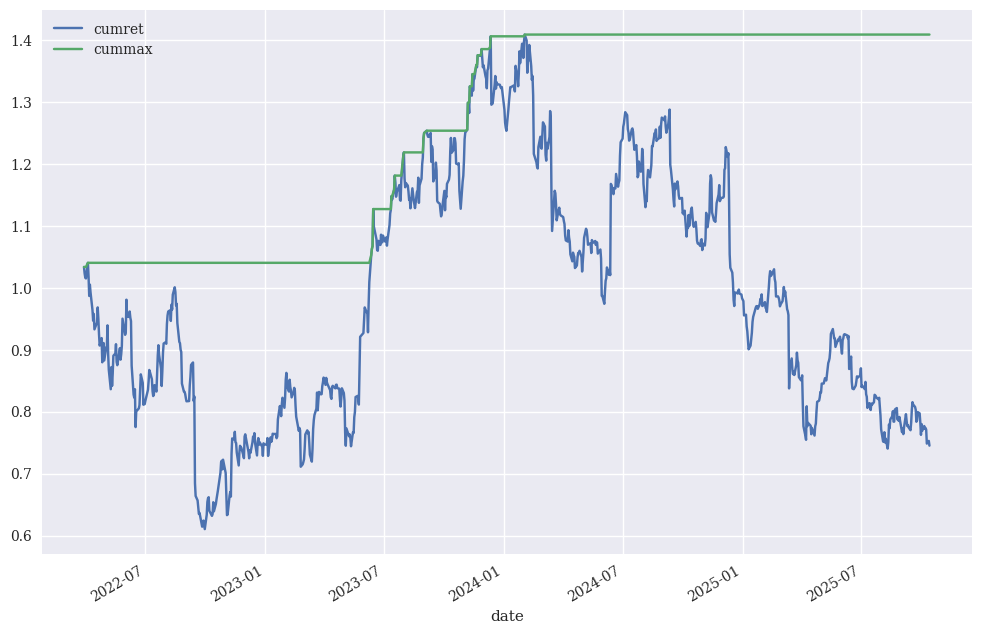

In [61]:
data['cumret'] = data['returns'].cumsum().apply(np.exp)
data['cummax'] = data['cumret'].cummax()
data[['cumret', 'cummax']].plot(figsize=(12, 8))

In [62]:
drawdown = data['cummax'] - data['cumret']
# The difference between the cumulative max and the cumulative return is the drawdown 
drawdown.max()

np.float64(0.6680500688002137)

In [63]:
temp = drawdown[drawdown == 0]
periods = (temp.index[1:].to_pydatetime() - temp.index[:-1].to_pydatetime())

In [64]:
periods.max()

datetime.timedelta(days=434)